In [1]:
# --- Cell 1: imports + frozen artefacts ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from task4.img_prep.cifar_data import (build_known_loaders, build_unknown_loaders,
                                       NEAR_UNKNOWN, FAR_UNKNOWN)
from task4.backbones.resnet_cifar import CifarResNet18
from task4.methods.proser import PROSER
from task4.evaluations.metrics import extract_outputs
from task4.scores.scores import u_msp, u_mls, u_energy, Mahalanobis, u_placeholder_logp
from task4.evaluations.osr_metrics import osr_summary, acceptance_rate
from scipy.stats import spearmanr

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA_ROOT = '../../datasets'
MODELS = ['vanilla', 'gcsc', 'proser']
splits = load_results('../../shared/splits/cifar10_seed6304.json')
CLASSES = splits['classes']

FROZEN = load_results('../results/scores.json')          
KNOWN = {m: dict(np.load(f'../../datasets/cache/task4_{m}_known.npz')) for m in MODELS}
KSCORE = {m: dict(np.load(f'../../datasets/cache/task4_{m}_scores_known.npz')) for m in MODELS}


def load_model(m):
    ck = torch.load(f'../../datasets/cache/task4_{m}.pt', map_location=device)
    model = CifarResNet18(num_classes=10).to(device)
    model.load_state_dict(ck['model']); model.eval()
    dummy = None
    if m == 'proser':
        meth = PROSER(ck['config']).to(device)
        meth.load_state_dict(ck['method'])
        dummy = meth.dummy.eval()
    return model, dummy, ck


def frozen_maha(m):
    mh = Mahalanobis()
    mh.means, mh.var = KSCORE[m]['maha_means'], KSCORE[m]['maha_var']
    return mh
print('frozen thresholds loaded for:', list(FROZEN['thresholds']))

frozen thresholds loaded for: ['vanilla', 'gcsc', 'proser']


In [2]:
# --- Cell 2: VERIFICATION ---
loaders = build_known_loaders(DATA_ROOT, splits, batch_size=128, eval_batch=512,
                              num_workers=0, seed=6304)
for m in MODELS:
    model, dummy, ck = load_model(m)
    o = extract_outputs(model, loaders['val'], device, keep_features=True)
    dl = np.abs(o['logits'] - KNOWN[m]['val_logits']).max()
    df = np.abs(o['features'] - KNOWN[m]['val_features']).max()
    line = f"{m:8s} best_epoch {ck['best_epoch']:3d} | max|dlogit| {dl:.2e} | max|dfeat| {df:.2e}"
    if dummy is not None:
        with torch.no_grad():
            d = dummy(torch.from_numpy(o['features']).to(device)).cpu().numpy()
        line += f" | max|ddummy| {np.abs(d - KNOWN[m]['val_dummy_logits']).max():.2e}"
    print(line)
    # frozen Mahalanobis reproduces the frozen known scores exactly
    mh = frozen_maha(m)
    same = np.allclose(mh.score(KNOWN[m]['test_features']), KSCORE[m]['mahalanobis_test'])
    print(f"         frozen Mahalanobis reproduces cached test scores: {same}")
    del model; torch.cuda.empty_cache()

vanilla  best_epoch 100 | max|dlogit| 0.00e+00 | max|dfeat| 0.00e+00
         frozen Mahalanobis reproduces cached test scores: True
gcsc     best_epoch  91 | max|dlogit| 0.00e+00 | max|dfeat| 0.00e+00
         frozen Mahalanobis reproduces cached test scores: True
proser   best_epoch   9 | max|dlogit| 0.00e+00 | max|dfeat| 0.00e+00 | max|ddummy| 0.00e+00
         frozen Mahalanobis reproduces cached test scores: True


In [3]:
# --- Cell 3: CIFAR 10 load ---
unk = build_unknown_loaders(DATA_ROOT, download=False)
UNK = {}
for m in MODELS:
    model, dummy, _ = load_model(m)
    UNK[m] = {}
    for g in ['near', 'far']:
        o = extract_outputs(model, unk[g]['loader'], device, keep_features=True)
        UNK[m][f'{g}_logits'], UNK[m][f'{g}_features'] = o['logits'], o['features']
        if dummy is not None:
            with torch.no_grad():
                UNK[m][f'{g}_dummy_logits'] = dummy(
                    torch.from_numpy(o['features']).to(device)).cpu().numpy()
    np.savez_compressed(f'../../datasets/cache/task4_{m}_unknown.npz', **UNK[m])
    print(m, {k: v.shape for k, v in UNK[m].items()})
    del model; torch.cuda.empty_cache()

vanilla {'near_logits': (800, 10), 'near_features': (800, 512), 'far_logits': (800, 10), 'far_features': (800, 512)}
gcsc {'near_logits': (800, 10), 'near_features': (800, 512), 'far_logits': (800, 10), 'far_features': (800, 512)}
proser {'near_logits': (800, 10), 'near_features': (800, 512), 'near_dummy_logits': (800, 5), 'far_logits': (800, 10), 'far_features': (800, 512), 'far_dummy_logits': (800, 5)}


In [4]:
# --- Cell 4:  ---
U = {}
for m in MODELS:
    mh = frozen_maha(m)
    U[m] = {k: {'test': KSCORE[m][f'{k}_test']}
            for k in FROZEN['thresholds'][m]}
    for g in ['near', 'far']:
        z, f = UNK[m][f'{g}_logits'], UNK[m][f'{g}_features']
        U[m]['msp'][g], U[m]['mls'][g] = u_msp(z), u_mls(z)
        U[m]['energy'][g], U[m]['mahalanobis'][g] = u_energy(z), mh.score(f)
        if m == 'proser':
            U[m]['placeholder'][g] = u_placeholder_logp(z, UNK[m][f'{g}_dummy_logits'])
    print(m, list(U[m]))

vanilla ['msp', 'mls', 'energy', 'mahalanobis']
gcsc ['msp', 'mls', 'energy', 'mahalanobis']
proser ['msp', 'mls', 'energy', 'mahalanobis', 'placeholder']


In [5]:
# --- Cell 5: full metric grid; print Table 1 (Vanilla, four scores) ---
GRID = {m: {k: osr_summary(d['test'], d['near'], d['far'],
                           FROZEN['thresholds'][m][k]['tau'])
            for k, d in U[m].items()} for m in MODELS}

hdr = (f"{'score':12s} {'AUROC near':>10s} {'far':>7s} {'all':>7s} | "
       f"{'reject near':>11s} {'far':>7s} {'all':>7s} | {'test accept':>11s}")
print('TABLE 1 — Vanilla\n' + hdr)
for k in ['msp', 'mls', 'energy', 'mahalanobis']:
    r = GRID['vanilla'][k]
    print(f"{k:12s} {r['auroc_near']:10.4f} {r['auroc_far']:7.4f} {r['auroc_all']:7.4f} | "
          f"{r['rej_near']:11.4f} {r['rej_far']:7.4f} {r['rej_all']:7.4f} | {r['test_acceptance']:11.4f}")

TABLE 1 — Vanilla
score        AUROC near     far     all | reject near     far     all | test accept
msp              0.8063  0.8921  0.8492 |      0.2938  0.4288  0.3613 |      0.9452
mls              0.7826  0.8896  0.8361 |      0.3225  0.5112  0.4169 |      0.9516
energy           0.7827  0.8904  0.8366 |      0.3337  0.5188  0.4263 |      0.9523
mahalanobis      0.7968  0.9136  0.8552 |      0.2863  0.5075  0.3969 |      0.9455


In [6]:
# --- Cell 6: Table 2 (method comparison) ---
ROWS = [('vanilla', 'mls'), ('gcsc', 'mls'), ('proser', 'mls'), ('proser', 'placeholder')]
csa = FROZEN['csa']
print('TABLE 2\n' + f"{'model / score':22s} {'CSA':>7s} | {'AUROC near':>10s} {'far':>7s} | "
      f"{'reject near':>11s} {'far':>7s} | {'test accept':>11s}")
for m, k in ROWS:
    r = GRID[m][k]
    print(f"{m + ' / ' + k:22s} {csa[m]:7.4f} | {r['auroc_near']:10.4f} {r['auroc_far']:7.4f} | "
          f"{r['rej_near']:11.4f} {r['rej_far']:7.4f} | {r['test_acceptance']:11.4f}")

print('\nMahalanobis AUROC (all) by model:',
      {m: round(GRID[m]['mahalanobis']['auroc_all'], 4) for m in MODELS})

TABLE 2
model / score              CSA | AUROC near     far | reject near     far | test accept
vanilla / mls           0.9461 |     0.7826  0.8896 |      0.3225  0.5112 |      0.9516
gcsc / mls              0.9507 |     0.7958  0.9088 |      0.3287  0.5625 |      0.9487
proser / mls            0.9438 |     0.8028  0.9145 |      0.3212  0.5537 |      0.9525
proser / placeholder    0.9438 |     0.7901  0.9059 |      0.3000  0.5075 |      0.9533

Mahalanobis AUROC (all) by model: {'vanilla': 0.8552, 'gcsc': 0.8427, 'proser': 0.861}


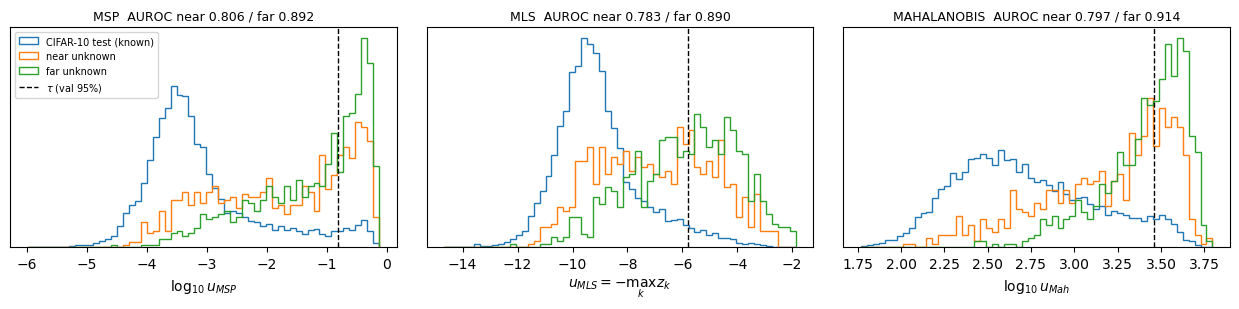

In [7]:
# --- Cell 7: required figure — Vanilla score distributions for MSP, MLS, Mahalanobis ---
import matplotlib.pyplot as plt
panels = [('msp', r'$\log_{10} u_{MSP}$', np.log10),
          ('mls', r'$u_{MLS} = -\max_k z_k$', lambda a: a),
          ('mahalanobis', r'$\log_{10} u_{Mah}$', np.log10)]
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.2))
for a, (k, lab, tf) in zip(ax, panels):
    d = U['vanilla'][k]; tau = FROZEN['thresholds']['vanilla'][k]['tau']
    lo = min(tf(d[s]).min() for s in d); hi = max(tf(d[s]).max() for s in d)
    bins = np.linspace(lo, hi, 60)
    for s, name in [('test', 'CIFAR-10 test (known)'), ('near', 'near unknown'), ('far', 'far unknown')]:
        a.hist(tf(d[s]), bins=bins, density=True, histtype='step', lw=1.4, label=name)
    a.axvline(tf(np.array([tau]))[0], c='k', ls='--', lw=1, label=r'$\tau$ (val 95%)')
    r = GRID['vanilla'][k]
    a.set_title(f"{k.upper()}  AUROC near {r['auroc_near']:.3f} / far {r['auroc_far']:.3f}", fontsize=9)
    a.set_xlabel(lab); a.set_yticks([])
ax[0].legend(fontsize=7)
plt.tight_layout(); plt.savefig('../../report/figures/task4_score_distributions.png', dpi=200)
plt.show()

In [8]:
# --- Cell 8: for rq1 ---
PER_CLASS = {}
for m, k in ROWS:
    tau = FROZEN['thresholds'][m][k]['tau']
    PER_CLASS[f'{m}/{k}'] = {}
    for g in ['near', 'far']:
        names = np.array(unk[g]['names']); acc = U[m][k][g] <= tau
        for n in (NEAR_UNKNOWN if g == 'near' else FAR_UNKNOWN):
            PER_CLASS[f'{m}/{k}'][n] = float(acc[names == n].mean())

print(f"{'class':13s}" + ''.join(f"{r:>20s}" for r in PER_CLASS))
for n in NEAR_UNKNOWN + FAR_UNKNOWN:
    print(f"{n:13s}" + ''.join(f"{PER_CLASS[r][n]:20.2f}" for r in PER_CLASS))


ABSORB = {}
tau = FROZEN['thresholds']['vanilla']['mls']['tau']
print('\nVanilla absorption (top predicted CIFAR-10 label):')
for g in ['near', 'far']:
    names = np.array(unk[g]['names'])
    pred = UNK['vanilla'][f'{g}_logits'].argmax(1)
    acc = U['vanilla']['mls'][g] <= tau
    for n in (NEAR_UNKNOWN if g == 'near' else FAR_UNKNOWN):
        sel = names == n
        counts = np.bincount(pred[sel], minlength=10)
        top = counts.argmax()
        acc_counts = np.bincount(pred[sel & acc], minlength=10)
        ABSORB[n] = {'group': g, 'pred_counts_all': counts.tolist(),
                     'pred_counts_accepted': acc_counts.tolist(),
                     'n_accepted': int((sel & acc).sum())}
        print(f"  {g:4s} {n:13s} -> {CLASSES[top]:10s} {counts[top]:3d}/100 "
              f"| accepted {int((sel & acc).sum()):3d}")

class                 vanilla/mls            gcsc/mls          proser/mls  proser/placeholder
bus                          0.86                0.89                0.84                0.87
pickup_truck                 0.95                0.96                0.90                0.91
motorcycle                   0.38                0.36                0.31                0.39
tractor                      0.66                0.52                0.67                0.65
wolf                         0.79                0.78                0.78                0.79
fox                          0.61                0.65                0.70                0.72
leopard                      0.61                0.70                0.68                0.71
camel                        0.56                0.51                0.55                0.56
bottle                       0.42                0.37                0.35                0.42
bowl                         0.47                0.41       

In [9]:
# --- Cell 9: for rq 2---
keys = ['msp', 'mls', 'energy', 'mahalanobis']
pool = {k: np.r_[U['vanilla'][k]['test'], U['vanilla'][k]['near'], U['vanilla'][k]['far']]
        for k in keys}
RHO = {f'{a}~{b}': float(spearmanr(pool[a], pool[b])[0])
       for i, a in enumerate(keys) for b in keys[i + 1:]}
print('Spearman rank correlation (known test + all unknowns):')
for p, v in RHO.items():
    print(f'  {p:22s} {v:.3f}')

T = {k: FROZEN['thresholds']['vanilla'][k]['tau'] for k in keys}
DISAGREE = {}
for g in ['near', 'far']:
    mls_acc = U['vanilla']['mls'][g] <= T['mls']
    mah_acc = U['vanilla']['mahalanobis'][g] <= T['mahalanobis']
    DISAGREE[g] = {'MLS_accept_MAH_reject': int((mls_acc & ~mah_acc).sum()),
                   'MLS_reject_MAH_accept': int((~mls_acc & mah_acc).sum()),
                   'both_accept': int((mls_acc & mah_acc).sum())}
    print(g, DISAGREE[g])

Spearman rank correlation (known test + all unknowns):
  msp~mls                0.962
  msp~energy             0.961
  msp~mahalanobis        0.698
  mls~energy             1.000
  mls~mahalanobis        0.588
  energy~mahalanobis     0.587
near {'MLS_accept_MAH_reject': 40, 'MLS_reject_MAH_accept': 69, 'both_accept': 502}
far {'MLS_accept_MAH_reject': 68, 'MLS_reject_MAH_accept': 71, 'both_accept': 323}


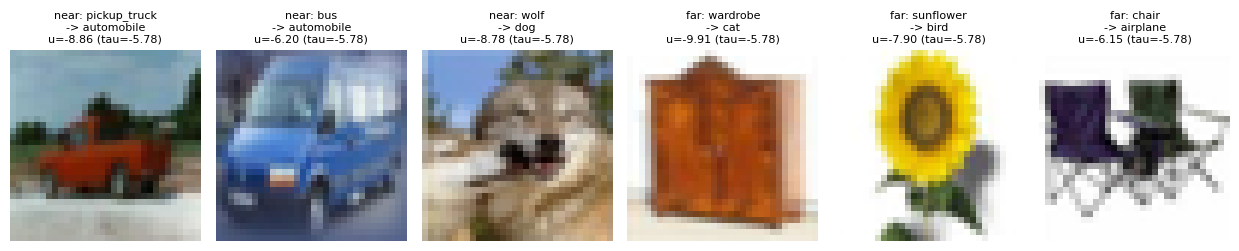

{'group': 'near', 'unknown_class': 'pickup_truck', 'pred': 'automobile', 'u_mls': -8.864232063293457, 'tau': -5.778449916839599, 'class_acceptance': 0.95, 'cifar100_test_index': 9662, 'pos': 772}
{'group': 'near', 'unknown_class': 'bus', 'pred': 'automobile', 'u_mls': -6.199170112609863, 'tau': -5.778449916839599, 'class_acceptance': 0.86, 'cifar100_test_index': 2019, 'pos': 151}
{'group': 'near', 'unknown_class': 'wolf', 'pred': 'dog', 'u_mls': -8.782828330993652, 'tau': -5.778449916839599, 'class_acceptance': 0.79, 'cifar100_test_index': 9942, 'pos': 795}
{'group': 'far', 'unknown_class': 'wardrobe', 'pred': 'cat', 'u_mls': -9.912796020507812, 'tau': -5.778449916839599, 'class_acceptance': 0.64, 'cifar100_test_index': 3378, 'pos': 285}
{'group': 'far', 'unknown_class': 'sunflower', 'pred': 'bird', 'u_mls': -7.899116516113281, 'tau': -5.778449916839599, 'class_acceptance': 0.54, 'cifar100_test_index': 3770, 'pos': 315}
{'group': 'far', 'unknown_class': 'chair', 'pred': 'airplane', 'u_

In [10]:
# --- Cell 10: failure cases ---

from torchvision.datasets import CIFAR100
raw = CIFAR100(DATA_ROOT, train=False, download=False).data     # uint8 (10000, 32, 32, 3)
rng = np.random.default_rng(6304)
tau = FROZEN['thresholds']['vanilla']['mls']['tau']
FAIL = []
for g in ['near', 'far']:
    names = np.array(unk[g]['names']); u = U['vanilla']['mls'][g]
    pred = UNK['vanilla'][f'{g}_logits'].argmax(1); acc = u <= tau
    cls = NEAR_UNKNOWN if g == 'near' else FAR_UNKNOWN
    ranked = sorted(cls, key=lambda n: (-acc[names == n].mean(), n))[:3]
    for n in ranked:
        cand = np.where((names == n) & acc)[0]
        i = int(rng.choice(cand))
        FAIL.append({'group': g, 'unknown_class': n, 'pred': CLASSES[pred[i]],
                     'u_mls': float(u[i]), 'tau': float(tau),
                     'class_acceptance': float(acc[names == n].mean()),
                     'cifar100_test_index': int(unk[g]['index'][i]), 'pos': i})

fig, ax = plt.subplots(1, 6, figsize=(12.5, 2.6))
for a, f in zip(ax, FAIL):
    a.imshow(raw[f['cifar100_test_index']]); a.axis('off')
    a.set_title(f"{f['group']}: {f['unknown_class']}\n-> {f['pred']}\n"
                f"u={f['u_mls']:.2f} (tau={f['tau']:.2f})", fontsize=8)
plt.tight_layout(); plt.savefig('../../report/figures/task4_failures.png', dpi=200)
plt.show()
for f in FAIL:
    print(f)

In [11]:
# --- Cell 11: save everything ---
save_results({
    'step': 'osr_eval', 'seed': 6304,
    'note': 'first notebook to load CIFAR-100; all thresholds read from scores.json',
    'grid': GRID, 'table2_rows': [f'{m}/{k}' for m, k in ROWS], 'csa': csa,
    'per_class_acceptance': PER_CLASS, 'absorption_vanilla': ABSORB,
    'spearman_vanilla': RHO, 'disagreement_mls_vs_mahalanobis': DISAGREE,
    'failure_cases': FAIL,
    'failure_rule': 'Vanilla MLS; per group top-3 classes by acceptance (ties alphabetical); '
                    'one accepted image per class drawn with seed 6304',
}, '../results/osr_eval.json')
print('saved results/osr_eval.json')

saved results/osr_eval.json
